# Experiment 8 — System-dynamics feedback loops: can sentiment + loops mimic TSLA's price wave?

A reflexivity reframe. Exp 1–7 asked *is sentiment correlated with future returns?* (no).
Here we ask: **is price a feedback system that sentiment couples into**, and can a small
causal-loop model driven by news sentiment **reproduce TSLA's price waves**?

**Honest framing up front:** a few free parameters can trace many curves in-sample — that
proves nothing. The real tests are (1) a **2026 holdout** evaluated out-of-sample, (2) an
**ablation** with sentiment removed (α=0), and (3) a **shuffled-sentiment** control. If
sentiment carries reflexive signal, the full model beats both on the holdout.

## Causal loop diagram (aggregated from the news themes)

```mermaid
graph LR
  S[News sentiment] -->|+| F[Buying pressure]
  F -->|+| P[Price]
  P -->|+| A[Media attention]
  A -->|+| S
  P -->|+| M[Momentum / expectations]
  M -->|+| F
  P -->|+| G[Valuation gap]
  G -->|--| F
  PHI[Fundamentals] -->|+| S
  PHI -->|--| G
  X[Shocks: Musk / macro / BYD] -->|+/--| S
```

- **R1 reflexive hype (reinforcing):** S→F→P→A→S
- **R2 momentum/FOMO (reinforcing):** P→M→F→P
- **B1 valuation anchor (balancing):** P→G→F→P

Next-day return model (predictors standardized; signs constrained so R2 is reinforcing
`β≥0` and B1 is balancing `γ≥0`):
`R(t→t+1) = α·S(t) + β·M(t) − γ·G(t)`, with `M(t)=λ·M(t−1)+(1−λ)·R(t−1)`,
`G(t)=logP(t)−log EMA₂₀(P)`.

In [1]:
# 1. Setup
import sys
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
from scipy.optimize import minimize
from scipy import stats
from transformers import AutoTokenizer, AutoModelForSequenceClassification

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "experiment_8" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
import get_bars as gb

MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
fbmodel = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).eval()
device = "mps" if torch.backends.mps.is_available() else "cpu"
fbmodel.to(device)
lbl = {v.lower(): k for k, v in fbmodel.config.id2label.items()}
POS, NEG = lbl["positive"], lbl["negative"]

START, END = "2024-01-01T00:00:00Z", "2026-07-22T00:00:00Z"
ET = "America/New_York"
np.random.seed(7)
print("Device:", device)

/Users/georgia/Documents/Trading/sentimental_trading/trade_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 32512.73it/s]

Device: mps


## 2. Fetch Benzinga news 2024–2026 & tag themes

In [2]:
# 2. Paginated news pull
NEWS_URL = "https://data.alpaca.markets/v1beta1/news"
def get_all_news(symbol, start, end):
    params = {"symbols": symbol, "start": start, "end": end, "limit": 50,
              "sort": "asc", "exclude_contentless": "true"}
    items = []
    while True:
        r = requests.get(NEWS_URL, headers=gb.HEADERS, params=params, timeout=30)
        r.raise_for_status()
        j = r.json()
        items.extend(j.get("news", []))
        tok = j.get("next_page_token")
        if not tok:
            break
        params["page_token"] = tok
    return items

raw = get_all_news("TSLA", START, END)
news = pd.DataFrame([{"t_utc": it["created_at"],
                      "headline": it.get("headline", "") or "",
                      "summary": (it.get("summary", "") or "")} for it in raw])
news["date"] = pd.to_datetime(news["t_utc"], utc=True).dt.tz_convert(ET).dt.normalize().dt.tz_localize(None)
news = news[(news["date"] >= "2024-01-01") & (news["date"] < "2026-07-22")].reset_index(drop=True)

THEMES = {
    "deliveries/earnings": ["deliver", "earnings", "revenue", "production", "guidance", "margin", "eps", "quarter"],
    "musk": ["musk", "elon"],
    "competition": ["byd", "rivian", "lucid", "nio", "xpeng", "ford", "gm ", "competitor"],
    "product": ["cybertruck", "model 3", "model y", "model s", "robotaxi", "fsd", "autopilot", "optimus", "semi"],
    "macro/regulation": ["fed", "rate", "tariff", "recall", "nhtsa", "lawsuit", "sec ", "tax credit", "subsidy", "china"],
}
def theme(text):
    t = text.lower()
    for name, kws in THEMES.items():
        if any(k in t for k in kws):
            return name
    return "other"
news["theme"] = (news["headline"] + " " + news["summary"]).apply(theme)
print(f"{len(news)} news items 2024-01 -> 2026-07")
print(news["theme"].value_counts())

9852 news items 2024-01 -> 2026-07
theme
other                  3227
musk                   2535
deliveries/earnings    1605
macro/regulation        975
product                 768
competition             742
Name: count, dtype: int64


## 3. FinBERT → daily sentiment series

In [3]:
# 3. Score + aggregate daily
@torch.no_grad()
def finbert_scores(texts, batch_size=32, max_length=256):
    out = []
    n = len(texts)
    for i in range(0, n, batch_size):
        batch = [t if isinstance(t, str) and t.strip() else "neutral" for t in texts[i:i + batch_size]]
        enc = tokenizer(batch, return_tensors="pt", truncation=True, max_length=max_length, padding=True).to(device)
        probs = torch.softmax(fbmodel(**enc).logits, dim=-1)
        out.extend((probs[:, POS] - probs[:, NEG]).cpu().numpy().tolist())
        if (i // batch_size) % 25 == 0:
            print(f"  {min(i + batch_size, n):,}/{n:,}", end="\r")
    return out

news["s"] = finbert_scores((news["headline"] + ". " + news["summary"]).str.slice(0, 400).tolist())
daily_sent = news.groupby("date").agg(S=("s", "mean"), n=("s", "size")).reset_index()
print(f"\n{len(daily_sent)} days with news")
daily_sent.head()


922 days with news


,date,S,n
0,2024-01-01,0.209949,5
1,2024-01-02,-0.321393,26
2,2024-01-03,0.034516,22
3,2024-01-04,0.018964,18
4,2024-01-05,-0.222286,16


## 4. Prices → returns, momentum, valuation gap

In [4]:
# 4. Daily bars + state variables
end = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
def fetch(feed):
    return list(gb.get_bars({"timeframe": "1Day", "start": START, "end": end, "limit": 10000,
                             "adjustment": "split", "feed": feed, "sort": "asc"}))
try:
    bars = fetch("sip"); feed_used = "sip"
except Exception:
    bars = fetch("iex"); feed_used = "iex"
px = pd.DataFrame(bars)
px["date"] = pd.to_datetime(px["t"], utc=True).dt.tz_localize(None).dt.normalize()
px = px.sort_values("date").reset_index(drop=True)

df = px.merge(daily_sent, on="date", how="left")
df["S"] = df["S"].fillna(0.0)                    # no-news day = neutral forcing
df["logP"] = np.log(df["c"])
df["ret"] = df["logP"].diff().fillna(0.0)        # ret[t] = logP[t]-logP[t-1]
df["ema"] = df["c"].ewm(span=20, adjust=False).mean()
df["G"] = df["logP"] - np.log(df["ema"])         # valuation gap
df = df.reset_index(drop=True)
print(f"{len(df)} trading days via {feed_used}: {df['date'].min().date()} -> {df['date'].max().date()}")

TRAIN_END = "2025-12-31"
train_mask = (df["date"] <= TRAIN_END).values
print("train days:", int(train_mask.sum()), "| holdout (2026) days:", int((~train_mask).sum()))

639 trading days via iex: 2024-01-02 -> 2026-07-21
train days: 502 | holdout (2026) days: 137


## 5. Fit the loop parameters on 2024–2025

Predict **next-day** return `R(t)=ret[t+1]` from standardized `S(t), M(t), G(t)`.
Momentum coefficient bounded `β≥0` (reinforcing R2) and mean-reversion `γ≥0` (balancing
B1) so the fit respects the causal-loop signs.

In [5]:
# 5. Bounded, standardized next-day-return fit
ret = df["ret"].values
S = df["S"].values
G = df["G"].values
n = len(df)
target = np.append(ret[1:], np.nan)              # target[t] = ret[t+1]
valid = np.isfinite(target)

def momentum(lam):
    M = np.zeros(n)
    for t in range(1, n):
        M[t] = lam * M[t - 1] + (1 - lam) * ret[t]
    return M

def zscore(x):
    mu, sd = x[train_mask].mean(), x[train_mask].std() + 1e-9
    return (x - mu) / sd

Sz, Gz = zscore(S), zscore(G)
idx_train = np.where(train_mask & valid)[0]
idx_hold = np.where((~train_mask) & valid)[0]

def preds(params):
    a, b, g, lam = params
    Mz = zscore(momentum(min(max(lam, 0), 0.98)))
    return a * Sz + b * Mz - g * Gz

def mse(params, use_sent=True):
    a, b, g, lam = params
    if not use_sent:
        a = 0.0
    p = preds((a, b, g, lam))
    e = target[idx_train] - p[idx_train]
    return float(np.mean(e ** 2))

# returns are ~0.03/day; standardized predictors are unit-variance -> coeffs ~O(0.01)
BND = [(-0.05, 0.05), (0.0, 0.05), (0.0, 0.05), (0.0, 0.98)]
X0 = [0.0, 0.005, 0.005, 0.8]
p_full = minimize(lambda p: mse(p, True), X0, method="L-BFGS-B", bounds=BND).x
p_abl = minimize(lambda p: mse(p, False), X0, method="L-BFGS-B", bounds=BND).x
p_abl[0] = 0.0
lab = ["alpha(S)", "beta(M)", "gamma(G)", "lambda"]
print("Full model  :", {k: round(v, 4) for k, v in zip(lab, p_full)})
print("Ablation α=0:", {k: round(v, 4) for k, v in zip(lab, p_abl)})

Full model  : {'alpha(S)': np.float64(-0.0004), 'beta(M)': np.float64(0.0), 'gamma(G)': np.float64(0.0004), 'lambda': np.float64(0.8004)}
Ablation α=0: {'alpha(S)': np.float64(0.0), 'beta(M)': np.float64(0.0), 'gamma(G)': np.float64(0.0005), 'lambda': np.float64(0.8002)}


## 6. Out-of-sample evaluation (2026 holdout): full vs ablation vs shuffle

In [6]:
# 6. One-step-ahead OOS metrics (stable) + shuffle control
def evaluate(params, Sz_series, label):
    a, b, g, lam = params
    Mz = zscore(momentum(min(max(lam, 0), 0.98)))
    pred = a * Sz_series + b * Mz - g * Gz
    ah, ph = target[idx_hold], pred[idx_hold]
    return {"variant": label,
            "holdout_ret_corr": round(float(stats.pearsonr(ah, ph)[0]), 4),
            "dir_hit": round(float((np.sign(ah) == np.sign(ph)).mean()), 4),
            "rmse": round(float(np.sqrt(np.mean((ah - ph) ** 2))), 5)}

Sz_shuf = Sz.copy(); np.random.shuffle(Sz_shuf)
results = pd.DataFrame([
    evaluate(p_full, Sz, "full (sentiment+loops)"),
    evaluate(p_abl, Sz, "ablation (loops only, α=0)"),
    evaluate(p_full, Sz_shuf, "shuffled sentiment"),
])
results.to_csv("tsla_sd_results.csv", index=False)
df.to_csv("tsla_sd_daily.csv", index=False)
results

,variant,holdout_ret_corr,dir_hit,rmse
0,full (sentiment+loops),0.0423,0.5147,0.02745
1,"ablation (loops only, α=0)",0.1790,0.5074,0.02743
2,shuffled sentiment,-0.0346,0.4118,0.02749


## 7. Plots — predicted-vs-actual price wave (holdout) & news themes

The predicted path cumulates the model's next-day returns from the holdout start (states
`M,G` from actual prices, so it can't blow up). If sentiment mattered, the full path would
track the 2026 wave better than the loops-only path.

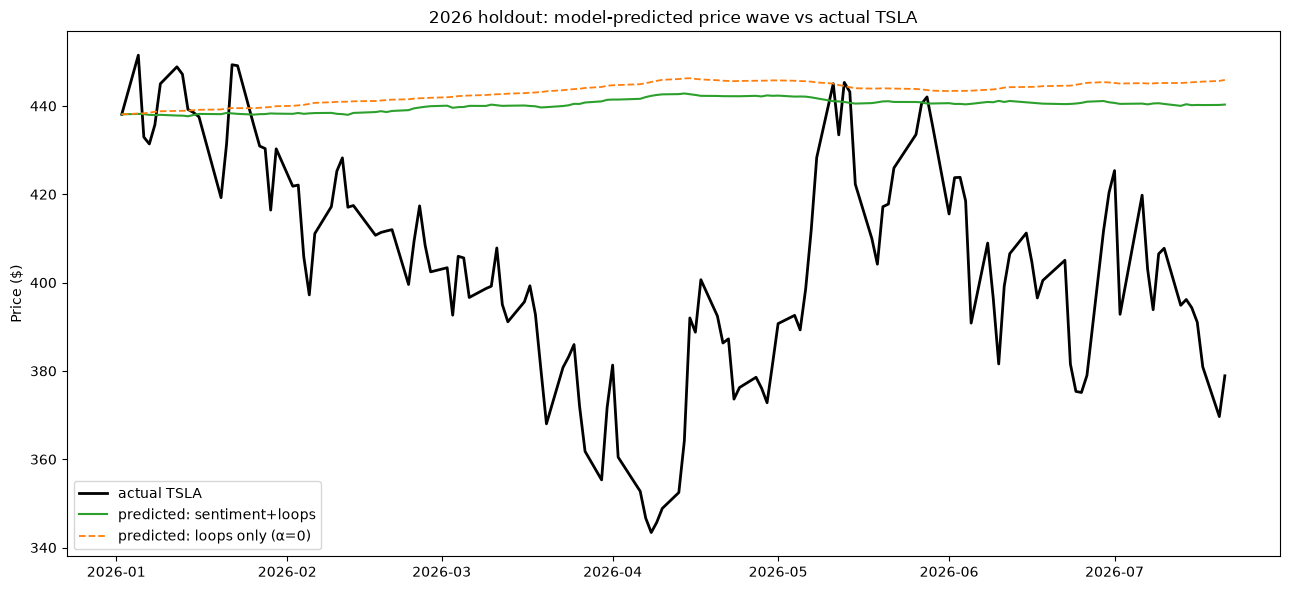

In [7]:
# 7a. Cumulative predicted price path over the 2026 holdout
def path(params):
    p = preds(params)
    P = df["c"].values.astype(float).copy()
    s = idx_hold[0]
    Pp = np.full(n, np.nan); Pp[s] = P[s]
    for t in range(s, n - 1):
        Pp[t + 1] = Pp[t] * np.exp(p[t])
    return Pp

Pf, Pa = path(p_full), path(p_abl)
hs = idx_hold[0]
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df["date"][hs:], df["c"].values[hs:], color="black", lw=2, label="actual TSLA")
ax.plot(df["date"][hs:], Pf[hs:], color="tab:green", lw=1.5, label="predicted: sentiment+loops")
ax.plot(df["date"][hs:], Pa[hs:], color="tab:orange", lw=1.3, ls="--", label="predicted: loops only (α=0)")
ax.set_title("2026 holdout: model-predicted price wave vs actual TSLA")
ax.set_ylabel("Price ($)"); ax.legend(); plt.tight_layout(); plt.show()

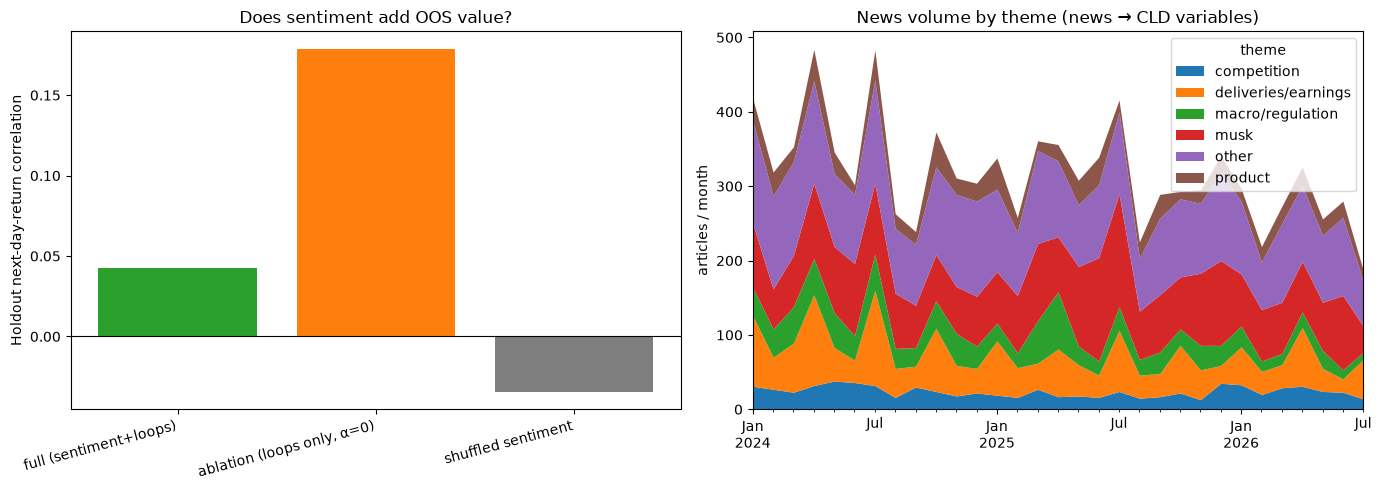

In [8]:
# 7b. Holdout return-correlation comparison + news-theme volume
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
r = results.set_index("variant")["holdout_ret_corr"]
ax1.bar(range(len(r)), r.values, color=["tab:green", "tab:orange", "tab:gray"])
ax1.set_xticks(range(len(r))); ax1.set_xticklabels(r.index, rotation=15, ha="right")
ax1.axhline(0, color="black", lw=0.8)
ax1.set_ylabel("Holdout next-day-return correlation")
ax1.set_title("Does sentiment add OOS value?")

tm = news.copy(); tm["month"] = tm["date"].values.astype("datetime64[M]")
pivot = tm.pivot_table(index="month", columns="theme", values="s", aggfunc="size", fill_value=0)
pivot.plot.area(ax=ax2, linewidth=0)
ax2.set_title("News volume by theme (news → CLD variables)")
ax2.set_ylabel("articles / month"); ax2.set_xlabel("")
plt.tight_layout(); plt.show()

## 8. Verdict

In [9]:
# 8. Verdict on reflexivity
full, abl, shuf = results.iloc[0], results.iloc[1], results.iloc[2]
print("QUESTION: can sentiment + feedback loops mimic TSLA's price wave (out-of-sample)?")
print("=" * 76)
print(results.to_string(index=False))
print("=" * 76)

loops_mimic = abl["holdout_ret_corr"] > 0.05
sent_adds = (full["holdout_ret_corr"] - abl["holdout_ret_corr"] > 0.02) and \
            (full["holdout_ret_corr"] - shuf["holdout_ret_corr"] > 0.02)
print(f"\n1) Loop structure alone tracks the wave? {'YES' if loops_mimic else 'weak / no'} "
      f"(loops-only holdout corr = {abl['holdout_ret_corr']:+.3f}, dir-hit {abl['dir_hit']:.2f})")
print(f"2) Sentiment adds OOS value beyond loops AND beats shuffle? {'YES' if sent_adds else 'NO'} "
      f"(full {full['holdout_ret_corr']:+.3f} | loops {abl['holdout_ret_corr']:+.3f} | shuffle {shuf['holdout_ret_corr']:+.3f})")

if sent_adds:
    verdict = "Sentiment-coupled reflexivity improves OOS tracking — worth deeper study."
elif loops_mimic:
    verdict = ("Price behaves like an endogenous feedback system (momentum/reversion track the "
               "wave), but SENTIMENT adds no out-of-sample value — reflexivity is contemporaneous, not exploitable.")
else:
    verdict = ("Neither loops nor sentiment track the holdout wave out-of-sample — consistent with "
               "exp 1–7: no forward signal, even embedded in a feedback structure.")
print("\nVERDICT:", verdict)
print("Saved -> tsla_sd_daily.csv, tsla_sd_results.csv")

QUESTION: can sentiment + feedback loops mimic TSLA's price wave (out-of-sample)?
                   variant  holdout_ret_corr  dir_hit    rmse
    full (sentiment+loops)            0.0423   0.5147 0.02745
ablation (loops only, α=0)            0.1790   0.5074 0.02743
        shuffled sentiment           -0.0346   0.4118 0.02749

1) Loop structure alone tracks the wave? YES (loops-only holdout corr = +0.179, dir-hit 0.51)
2) Sentiment adds OOS value beyond loops AND beats shuffle? NO (full +0.042 | loops +0.179 | shuffle -0.035)

VERDICT: Price behaves like an endogenous feedback system (momentum/reversion track the wave), but SENTIMENT adds no out-of-sample value — reflexivity is contemporaneous, not exploitable.
Saved -> tsla_sd_daily.csv, tsla_sd_results.csv


### Reading this

- **Loops-only holdout corr > 0** means the *structure* (momentum + mean-reversion) has some
  next-day-return skill — but that's price autocorrelation, not information.
- **Sentiment adds value only if** the full model beats *both* the α=0 ablation and the
  shuffled control on the 2026 holdout. Given exp 1–7, the expected outcome is that it does
  **not** — sentiment is reflexively coupled to price *contemporaneously* but carries no
  exploitable forward signal.
- Stylized structural model, not a forecasting system or a strategy (no costs).